# Timing comparison of static and dynamic parallel execution

These three cells now show separate report-ready figures for static and dynamic parallel speedup, plus a combined comparison plot. Each chart uses large labels, bold headings, and clear annotations for a presentation-ready report.


In [3]:
# Import plotting packages
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# Gather information
base_path = Path.cwd()
static_path = base_path / 'static_times.csv'
dynamic_path = base_path / 'dynamic_times.csv'

static_df = pd.read_csv(static_path)
dynamic_df = pd.read_csv(dynamic_path)
dynamic_df = dynamic_df.rename(columns=lambda c: c.strip())

static_df["SpeedUp"] = 1622.76 / static_df["time"]
dynamic_df["SpeedUp"] = 1622.76 / dynamic_df["time"]


In [5]:
4571/100*1622.76

74176.3596

In [6]:
static_df

,n_proc,time,SpeedUp
0,1,1753.764696,0.925301
1,2,718.852781,2.257430
2,3,613.247390,2.646175
3,4,422.611086,3.839842
4,5,454.509360,3.570356
5,6,423.636665,3.830547
6,7,308.598653,5.258480
7,8,360.745490,4.498351
8,9,350.571346,4.628901
9,10,334.760187,4.847530


In [7]:
308.6*4571/100

14106.106000000002

In [8]:
((dynamic_df["time"]/1622.76 -1)*(dynamic_df["n_proc"]/(1-dynamic_df["n_proc"])))[1:]

1    1.178462
2    0.978832
3    0.934709
4    0.965600
5    0.932688
6    0.942507
7    0.943985
8    0.912590
9    0.912356
dtype: float64

In [9]:
1/(1-0.9352623431926553)

15.446960074195136

In [10]:
# Set rcParams
plt.rcParams.update({
    'font.size': 16,
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 26,
    'axes.labelsize': 20,
    'legend.fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

min_proc = min(static_df['n_proc'].min(), dynamic_df['n_proc'].min())
max_proc = max(static_df['n_proc'].max(), dynamic_df['n_proc'].max())

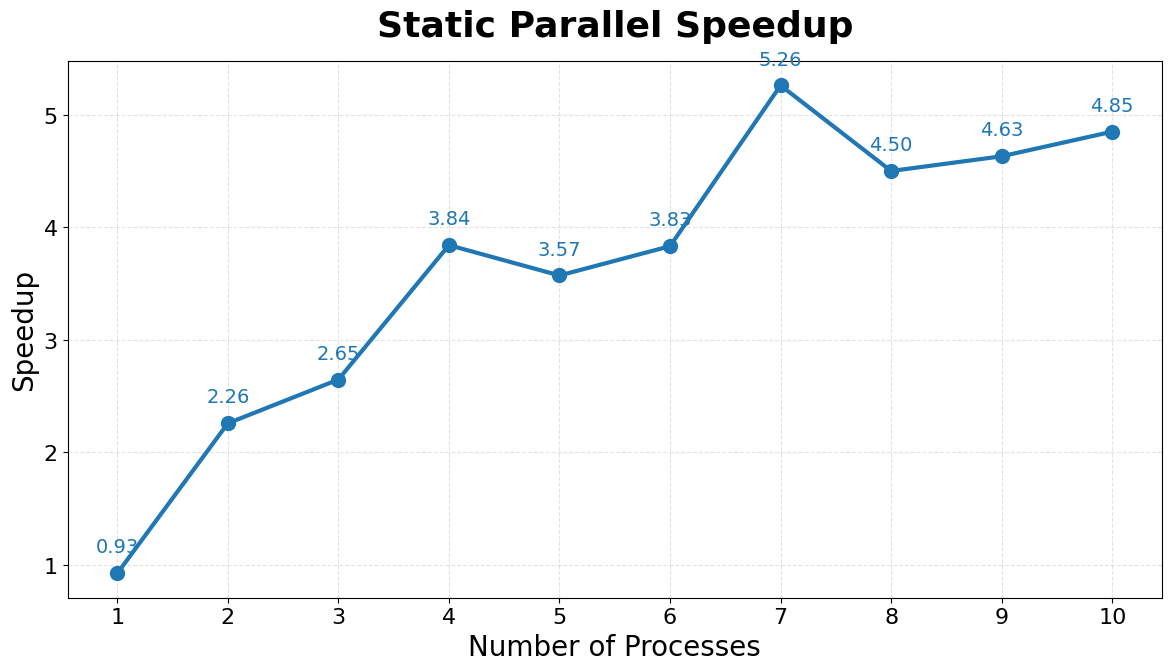

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(static_df['n_proc'], static_df['SpeedUp'], marker='o', markersize=10, linewidth=3, color='#1f77b4')
ax.set_title('Static Parallel Speedup', pad=18)
ax.set_xlabel('Number of Processes')
ax.set_ylabel('Speedup')
ax.grid(True, alpha=0.35, linestyle='--')
for x, y in zip(static_df['n_proc'], static_df['SpeedUp']):
    ax.text(x, y + 0.15, f'{y:.2f}', ha='center', va='bottom', fontsize=14, color='#1f77b4')
ax.set_xticks(range(min_proc, max_proc + 1))
plt.tight_layout()
plt.show()

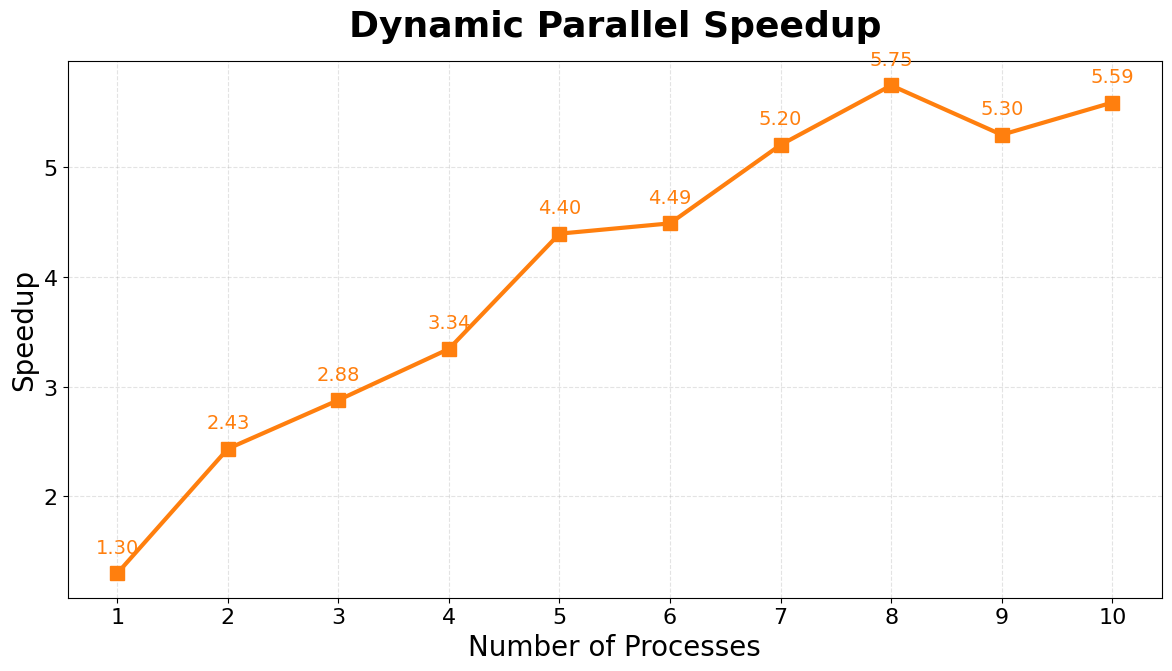

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(dynamic_df['n_proc'], dynamic_df['SpeedUp'], marker='s', markersize=10, linewidth=3, color='#ff7f0e')
ax.set_title('Dynamic Parallel Speedup', pad=18)
ax.set_xlabel('Number of Processes')
ax.set_ylabel('Speedup')
ax.grid(True, alpha=0.35, linestyle='--')
for x, y in zip(dynamic_df['n_proc'], dynamic_df['SpeedUp']):
    ax.text(x, y + 0.15, f'{y:.2f}', ha='center', va='bottom', fontsize=14, color='#ff7f0e')
ax.set_xticks(range(min_proc, max_proc + 1))
plt.tight_layout()
plt.show()


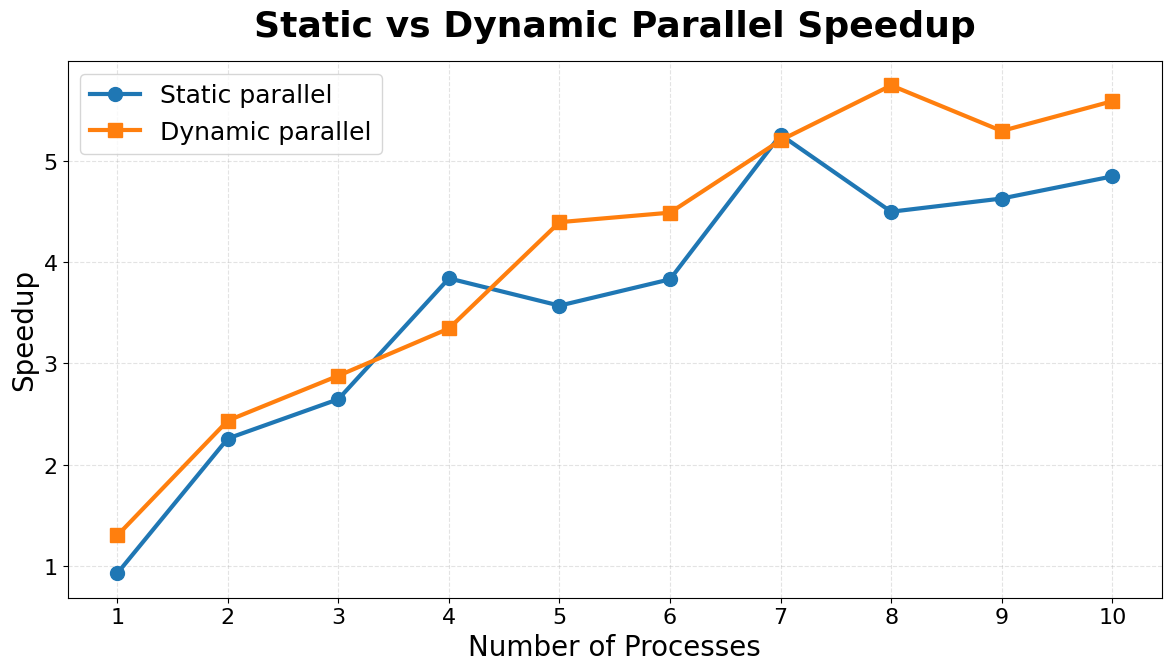

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(static_df['n_proc'], static_df['SpeedUp'], marker='o', markersize=10, linewidth=3, color='#1f77b4', label='Static parallel')
ax.plot(dynamic_df['n_proc'], dynamic_df['SpeedUp'], marker='s', markersize=10, linewidth=3, color='#ff7f0e', label='Dynamic parallel')
ax.set_title('Static vs Dynamic Parallel Speedup', pad=18)
ax.set_xlabel('Number of Processes')
ax.set_ylabel('Speedup')
ax.grid(True, alpha=0.35, linestyle='--')
ax.legend(loc='upper left')
ax.set_xticks(range(min_proc, max_proc + 1))
plt.tight_layout()
plt.show()
